## ESZA019 – Visao Computacional 2026.2
## Laboratório 3 – Alinhamento, Homografia 2D e Mosaico

### **INTEGRANTES**

- Eduarda Alexandre de Salles RA: 11202320551

- Gustavo de Paula Souza RA: 11202130568

- Paloma Cristina Santana RA:11201921396

### **CRONOGRAMA DO PROJETO**

#### Data de realização: 17/06/2026

#### Data de publicação: 28/06/2026



## 1. Introdução e Revisáo Teórica

O presente capítulo aborda os conceitos matemáticos e computacionais que sustentam o desenvolvimento do projeto. Inicialmente, descreve-se o processo de extração e correspondência de características em imagens digitais, seguido pelo estudo das transformações geométricas projetivas e os métodos estatísticos para filtragem de dados espúrios.

## 1.1 Detecção, Descrição e Correspondência de Feições (*Feature Matching*)

No escopo da Visão Computacional, uma feição (*feature*) ou ponto de interesse consiste em uma região de uma imagem que apresenta características estruturais marcantes e distintas, tais como cantos, bordas pronunciadas ou texturas específicas. O processo de identificação e comparação dessas estruturas entre duas imagens distintas subdivide-se em três etapas fundamentais que envolvem a detecção, a descrição e a correspondência.

A etapa inicial baseia-se no uso de algoritmos extratores para varrer a imagem e localizar os pontos-chave (*keypoints*). Entre os principais extratores da literatura, destaca-se o *Scale-Invariant Feature Transform* (SIFT), que é um algoritmo amplamente consolidado por sua robustez e por apresentar invariância a alterações de escala, rotação espacial e variações de iluminância. Como alternativa computacional de código aberto, o algoritmo *Oriented FAST and Rotated BRIEF* (ORB) foi desenvolvido como uma opção de alta eficiência e baixo custo de processamento, ideal para aplicações que demandam análise em tempo real.

Após a localização dos pontos de interesse por qualquer um desses métodos, o algoritmo gera um descritor para cada elemento, constituído por um vetor numérico que fornece um resumo matemático das propriedades visuais da vizinhança daquele ponto correspondente. Com os descritores calculados tanto para a imagem de consulta (*query image*) quanto para a imagem de cena (*train image*), executa-se o processo de *Feature Matching*. Esta operação emprega algoritmos de busca, como o *Brute-Force Matcher* (BFMatcher) ou o *Fast Library for Approximate Nearest Neighbors* (FLANN), para calcular a distância matemática, seja ela Euclidiana ou de Hamming, entre os vetores de ambas as imagens, classificando como correspondências potenciais os pares que apresentam as menores distâncias vetoriais.

In [ ]:
# Demonstração Prática: Detecção de Feições com ORB
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Inicializar o extrator ORB
orb = cv2.ORB_create()

print("Extrator ORB inicializado com sucesso para detecção e descrição.")

## 1.2 Transformações Geométricas e Homografia (*Homography*)

Embora a correspondência de feições seja eficaz para identificar pontos similares, ela não estabelece, de forma isolada, uma relação geométrica global entre os planos das imagens analisadas. Para mapear a projeção de um plano tridimensional capturado a partir de diferentes perspectivas ou ângulos de câmera, aplica-se o conceito matemático de Homografia. A Homografia configura-se como uma matriz de transformação projetiva de dimensão $3 \times 3$ que detém 8 graus de liberdade, sendo responsável por relacionar linearmente as coordenadas de um ponto $(x, y)$ na primeira imagem com as coordenadas correspondentes $(x', y')$ na segunda superfície de projeção.

Essa relação geométrica obedece a uma equação linear homogênea onde o vetor de coordenadas transformadas é obtido multiplicando-se a matriz de homografia $H$ pelo vetor de coordenadas originais:

$$
\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} = H \begin{bmatrix} x \\ y \\ 1 \end{bmatrix} = \begin{bmatrix} h_{11} & h_{12} & h_{13} \\ h_{21} & h_{22} & h_{23} \\ h_{31} & h_{32} & h_{33} \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}
$$

A estimativa adequada dos parâmetros que compõem essa matriz requer a identificação de, no mínimo, 4 pares de pontos correspondentes que não sejam colineares. Na biblioteca OpenCV, o cálculo dessa estrutura matricial é realizado por meio da função `cv2.findHomography`. Uma vez estabelecida a matriz de homografia, torna-se viável a aplicação de funções de transformação perspectiva, tais como a `cv2.perspectiveTransform`, o que permite projetar a geometria original de um objeto e delimitar suas bordas na imagem de destino de forma exata, independentemente de eventuais rotações ou inclinações sofridas pelo plano.

## 1.3 Robustez na Estimativa e o Algoritmo RANSAC

Em cenários práticos, o processo de correspondência de feições está sujeito a imperfeições operacionais. Dentre os pares de pontos homologados pelo algoritmo de busca, coexistem dados geometricamente coerentes, denominados *inliers*, e correspondências incorretas, chamadas de *outliers*, as quais são geradas por ruídos de captura, oclusões parciais ou texturas padronizadas repetitivas na cena. A inserção direta de todos os pontos encontrados e a presença de *outliers* no cálculo matemático causariam distorções severas na matriz de homografia final, inviabilizando a localização correta do objeto.

Para mitigar a influência desses ruídos e conferir robustez ao sistema, integra-se ao pipeline de cálculo o algoritmo *RANdom SAmple Consensus* (RANSAC). Este método atua de maneira iterativa a partir da seleção aleatória de um subconjunto mínimo contendo apenas 4 pares de correspondências para computar uma matriz de homografia candidata. Na sequência, o algoritmo avalia todos os demais pontos da cena face a essa matriz provisória, contabilizando quantos elementos se alinham dentro de um limiar (*threshold*) de tolerância preestabelecido. O processo é repetido sistematicamente por um número finito de iterações, adotando como resultado definitivo a matriz que obtiver o maior consenso de pontos válidos (*inliers*). A associação sequencial entre os extratores de feições, o cálculo matricial da Homografia e o filtro estatístico RANSAC consolida o fluxo de processamento clássico empregado em visão computacional para detecção, rastreamento de objetos planos e alinhamento de imagens.

In [ ]:
# Estrutura base do pipeline completo usando OpenCV (findHomography + RANSAC)
# Nota: Esta linha está comentada pois necessita de pontos reais extraídos (src_pts e dst_pts)
# M_jacobiana, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

print("Pipeline estruturado: Extrator -> Matcher -> RANSAC Homography.")

## 2. Referenciais Teóricos em Visão Computacional

O processo de alinhamento de imagens, detecção de objetos e geração de panoramas (*image stitching*) em Visão Computacional baseia-se em um pipeline geométrico e matemático fundamental dividido em quatro etapas principais:

### 2.1. Detecção de Feições, Casamento de Pontos e Geometria de Projeção

Esta seção aborda os fundamentos conceituais para a identificação de correspondências estruturais entre diferentes perspectivas e a sua aplicação para a localização de objetos e reconstrução de cenas.

#### 1. Detecção de Feições e Extração de Descritores
O primeiro passo consiste em identificar pontos de interesse (*keypoints*) estruturais nas imagens (como cantos, bordas ou texturas marcantes) que possuam propriedades de invariância a mudanças de escala, rotação e variações de iluminação.
* **Mapeamento:** Algoritmos matemáticos isolam esses pontos de interesse através de métodos como a Diferença de Gaussianas (*Difference of Gaussians* - DoG) ou análise de gradientes orientados. A partir disso, são gerados vetores descritores locais que quantificam matematicamente a distribuição de texturas e intensidades de pixels na região vizinha ao ponto detectado.

#### 2. Correspondência de Pontos (*Keypoint Matching*)
Com os descritores extraídos de duas imagens distintas (uma imagem de consulta e uma imagem de cena), calcula-se a proximidade matemática entre os vetores para estabelecer a similaridade e encontrar pares equivalentes:
* **Métricas de Proximidade:** Utiliza-se o cálculo da distância Euclidiana entre os vetores de características. Para garantir a reciprocidade espacial e mitigar associações erróneas, adota-se critérios de verificação cruzada, onde um ponto na primeira imagem deve reconhecer e ser reconhecido pelo correspondente na segunda imagem de forma mútua.
* **Estruturação de Dados:** Para cenários com alta densidade de feições, empregam-se estruturas baseadas em árvores de decisão espacial (como árvores KD) para aproximar a busca dos vizinhos mais próximos de maneira computacionalmente eficiente.
* **Teste de Razão de Distância:** Técnica que avalia a ambiguidade de uma correspondência comparando a distância do melhor candidato com a distância do segundo melhor candidato. Se a razão entre as distâncias for superior a um limiar estabelecido (frequentemente entre $0.7$ e $0.8$), o ponto é descartado por falta de distinção estrutural clara na cena.

#### 3. Estimativa de Homografia e Robustez Estatística
A relação geométrica que projeta e alinha os pontos de um plano em outra perspectiva é definida por uma matriz de transformação linear espacial chamada **Matriz de Homografia ($H$)**, de dimensão $3 \times 3$.
* **Graus de Liberdade:** Do ponto de vista algébrico, são necessários, no mínimo, **4 pares de pontos correspondentes não colineares** para solucionar o sistema de equações lineares e estimar a matriz $H$.
* **Consenso Estatístico (RANSAC):** Devido à presença inevitável de ruídos causados por casamentos incorretos de pontos, aplica-se de forma iterativa o algoritmo RANSAC (*RANdom SAmple Consensus*). Este método seleciona subconjuntos mínimos de pontos para testar modelos geométricos hipotéticos, isolando os casamentos discrepantes (*outliers*) e retendo apenas as correspondências geometricamente válidas (*inliers*).
* **Validação de Densidade:** Para evitar projeções inconsistentes em cenários onde o objeto de interesse não está presente, estabelece-se um limite mínimo de pontos validados pelo modelo estatístico antes de homologar a transformação geométrica global.

#### 4. Transformação de Perspectiva e Delimitação Espacial
A matriz de homografia ideal permite calcular a nova posição projetada de qualquer coordenada pertencente ao plano original.
* **Localização Espacial:** Ao aplicar esta matriz sobre as coordenadas limítrofes que definem os quatro cantos do objeto original, determinam-se com precisão as novas coordenadas de contorno (*bounding box*) na cena complexa, independentemente do nível de rotação ou inclinação sofrido pelo objeto.

---

### 2.2. Modelagem Matemática da Homografia e Aplicações Industriais

Esta seção aprofunda o rigor matemático por trás da transformação planar e discute as condições físicas limitantes e as aplicações práticas da homografia na indústria de tecnologia.

#### 1. Formulação Algébrica
A Homografia realiza um mapeamento projetivo entre dois espaços planos bidimensionais. Se um ponto físico pertencente a uma superfície for projetado como as coordenadas $(x_1, y_1)$ no plano da primeira imagem e como $(x_2, y_2)$ na segunda, a relação de translação, rotação e escala é governada por coordenadas homogêneas através da seguinte equação matricial:

$$\begin{bmatrix} x_1 \\ y_1 \\ 1 \end{bmatrix} = H \begin{bmatrix} x_2 \\ y_2 \\ 1 \end{bmatrix} = \begin{bmatrix} h_{11} & h_{12} & h_{13} \\ h_{21} & h_{22} & h_{23} \\ h_{31} & h_{32} & h_{33} \end{bmatrix} \begin{bmatrix} x_2 \\ y_2 \\ 1 \end{bmatrix}$$

#### 2. Condições Físicas de Validade Geométrica
A suposição de que duas imagens estão relacionadas por uma única matriz de homografia pura exige a obediência estrita a pelo menos uma de duas condições do mundo real:
1. **Coplanaridade da Cena:** Todos os pontos de interesse capturados devem residir estritamente sobre uma superfície plana tridimensional (como superfícies de livros, fachadas de edifícios ou terrenos planos vistos de grande altitude). Elementos tridimensionais que se projetem para fora deste plano quebram a relação matemática, introduzindo erros de paralaxe.
2. **Centro de Projeção Fixo (Rotação Pura):** Caso o centro óptico da câmera permaneça estático no espaço (sofrer apenas movimentos angulares de rotação, como *pan* e *tilt*), os efeitos de paralaxe são anulados. Nesta condição específica, **qualquer cena arbitrária**, mesmo com profundidades complexas, obedecerá rigorosamente à homografia, viabilizando o alinhamento perfeito de perspectivas.

#### 3. Aplicações Práticas e Limitações do Modelo Clássico
Além da construção de panoramas, a modelagem geométrica por homografia resolve problemas fundamentais em diversos setores:
* **Retificação de Perspectiva (*Perspective Correction*):** Processo que elimina a distorção de inclinação introduzida pelo ângulo da lente ao capturar um documento ou objeto plano. O mapeamento reconverte a perspectiva distorcida para uma malha retangular perfeita, emulando uma projeção ortogonal de topo ideal para fins de escaneamento e legibilidade.
* **Superfícies e Outdoors Virtuais (*Virtual Billboards*):** Amplamente utilizado em transmissões de eventos desportivos para inserção ou substituição dinâmica de publicidades. O plano de destino (a placa real no campo de jogo) fornece as coordenadas limite para o cálculo da homografia, permitindo que a imagem digital do novo anúncio seja projetada, distorcida e fundida perfeitamente respeitando a inclinação e a perspetiva da câmara de transmissão.
* **Desafios na Costura de Mosaicos:** Alinhamentos simplificados que realizam apenas a sobreposição geométrica direta de pixels tendem a falhar em ambientes dinâmicos do mundo real. Deslocamentos translacionais mínimos da câmara introduzem descontinuidades na junção das imagens (*seams*). Além disso, variações automáticas de foco e tempo de exposição do sensor geram transições abruptas de luz e nitidez ao longo da linha de costura. A mitigação destes artefactos requer modelos mais complexos de compensação de irradiância e algoritmos avançados de fusão por máscaras de bandas múltiplas (*multi-band blending*).


## 3. PROCEDIMENTOS EXPERIMENTAIS

Esta seção documenta a lógica operacional, a arquitetura de software e o protocolo metodológico adotados na execução das atividades experimentais. O objetivo consiste em coletar dados empíricos para validar os conceitos de casamento de características (*feature matching*), restrições geométricas por graus de liberdade e homografia aplicada a sistemas planares e fluxos contínuos.

---#

## 3.1. PARTE 3 (A): Feature Matching e Homografia Estática

Este módulo aborda o procedimento experimental para inicializar dois sensores ópticos de forma paralela, congelar o buffer de imagem no mesmo instante temporal e gerar o panorama estático comparativo para dois cenários distintos (Pessoa e Objeto de Superfície Plan#a).

### 1. Alinhamento e Posicionamento Físico dos Sensores
O arranjo experimental exige o posicionamento de dois sensores ópticos idênticos instalados em suportes rígidos paralelos. O primeiro sensor (Câmera 1) permanece fixo, orientado perpendicularmente ao centro do cenário de teste para atuar como o plano de referência estável do sistema. O segundo sensor (Câmera 2) deve ser rotacionado angularmente de forma lateral (movimento de *pan*). A rotação da Câmera 2 é ajustada continuamente até certificar-se visualmente de que a região comum de sobreposição visual entre as duas perspectivas distintas seja de, no mínimo#, 50%.

### 2. Ensaio Estático com Elemento Humano (Cenário 1 — Pessoa)
Para a validação do primeiro cenário, o indivíduo é posicionado de forma estática no centro do plano de intersecção focal de ambos os sensores. O ambiente deve ser provido de iluminação homogênea para mitigar sombras espúrias ou oclusões dinâmicas que possam corromper os gradientes locais de textura. O operador aciona o comando de captura simultânea (tecla `ESPAÇO`), registrando e congelando ambas as matrizes de pixels no mesmo milissegundo físico sob os nomes de arquivo `imagem1_teste_simultaneo_pessoa.jpg` e `imagem2_teste_simultaneo_pes#soa.jpg`.

### 3. Ensaio Estático com Objeto Planar (Cenário 2 — Livro)
Substitui-se o elemento humano por um objeto rígido e predominantemente planar (neste ensaio, o livro *"OpenGL Programming Guide"*) sobre a mesa de testes, mantendo o fundo com o teclado e elementos do laboratório. O objeto deve ser centralizado dentro da zona de sobreposição de 50%, garantindo que sua capa forneça uma alta densidade de texturas e contrastes locais. O comando de disparo síncrono é executado novamente para salvar o segundo par de imagens de teste em disco (`imagem1_teste_simultaneo_livro.jpg` e `imagem2_teste_simultaneo_livro.jpg`) para posterior análise# geométrica.

### 4. Engenharia do Sistema Concorrente de Captura
Para anular a latência natural de inicialização de barramentos de comunicação do sistema operacional, a arquitetura do software delega a captura de quadros a fluxos de execução (*threads*) secundários e independentes operando em segundo plano. Cada fluxo atualiza continuamente um buffer isolado na memória a intervalos regulados de tempo. Para evitar a ocorrência de corrupção de dados por concorrência (*race conditions*), um mecanismo de exclusão mútua (*mutex lock*) protege o buffer no exato momento em que o fluxo principal intercepta o evento do teclado e solicita a leitura síncrona do último quadro íntegro de amb#os os sensores.

### 5. Extração de Feições e Filtragem Estatística (SIFT)
As imagens salvas são convertidas para escala de cinza e submetidas ao extrator de feições estruturais SIFT (*Scale-Invariant Feature Transform*). O algoritmo localiza os pontos de interesse através da Diferença de Gaussianas (DoG) e gera vetores descritores locais de 128 dimensões, invariantes a rotações e escalas. 

As correspondências iniciais são calculadas através da distância Euclidiana entre os descritores. Para eliminar falsas associações induzidas por padrões repetitivos na cena, aplica-se o Teste de Razão de David Lowe com um limiar de 0,75; se a razão entre a distância do melhor candidato e a do segundo melhor for superior a este teto, o par é descartado por ambiguidade estrutural, gerando o volume total de correspondências vali#dadas pré-geometria.

### 6. Estimação Geométrica Global e Composição do Mosaico
O sistema reorganiza as coordenadas dos pontos sobreviventes e calcula duas matrizes de transformação de perspectiva de dimensão $3 \times 3$:
* **Mínimos Quadrados Tradicionais ($H_{\text{ls}}$):** Estima a matriz minimizando globalmente a soma dos erros quadráticos de projeção de todos os pontos.
* **RANSAC Robusto ($H_{\text{ransac}}$):** Seleciona iterativamente subconjuntos mínimos de correspondências não colineares para construir modelos de consenso contra um limiar de tolerância geométrica de 5,0 pixels, isolando ruídos (*outliers*) e retendo apenas a matriz baseada nos pontos estritamente corretos (*inliers*).

A matriz de homografia obtida pelo RANSAC é aplicada para distorcer a perspectiva da imagem de origem sobre um espaço ampliado (*canvas*). A fusão com a imagem de destino é realizada através de uma máscara lógica booleana baseada em luminância, sobrepondo as duas perspectivas. Por fim, um algoritmo de análise de contornos isola o mosaico resultante e recorta automaticamente a menor caixa delimitadora retangular possível, removendo as áreas vazias quando o comando de finalização é enviado pelo operador.


[TESTE_SIMULTANEO_PESSOA] Ajuste as câmeras (50% de sobreposição).
Aperte ESPAÇO para capturar as DUAS imagens no mesmo milissegundo...
Fotos capturadas simultaneamente:
 - imagem1_teste_simultaneo_pessoa.jpg
 - imagem2_teste_simultaneo_pessoa.jpg

Iniciando o processamento matemático das imagens capturadas...

Total de pontos correspondentes validados pré-geometria: 27

--- Matriz de Homografia via Mínimos Quadrados Clássicos ---
[[-2.19698011e+00  5.27324911e+00  2.21457639e+02]
 [-2.18865961e+00  4.72717617e+00  2.97578729e+02]
 [-8.18125875e-03  1.81284334e-02  1.00000000e+00]]

--- Matriz de Homografia via RANSAC ---
[[-5.52875080e-01  3.26978911e-01  2.16393568e+02]
 [-2.55073743e-01  6.22204838e-01  1.27800816e+02]
 [-1.30534900e-03 -1.27101457e-04  1.00000000e+00]]

Resultado RANSAC: 6 Inliers | 21 Outliers


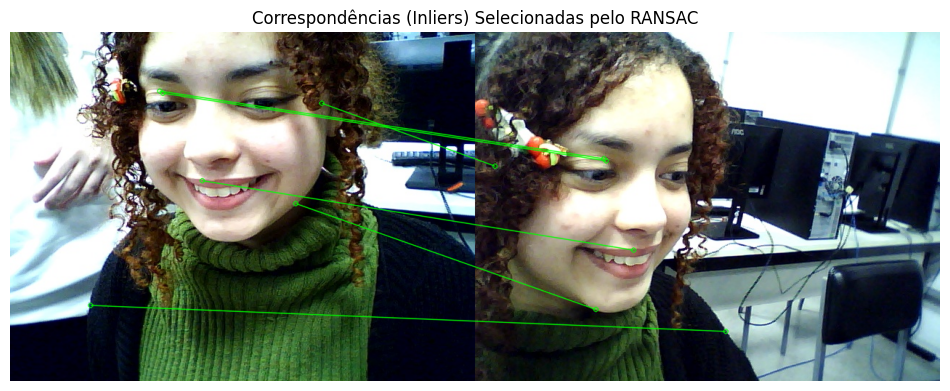

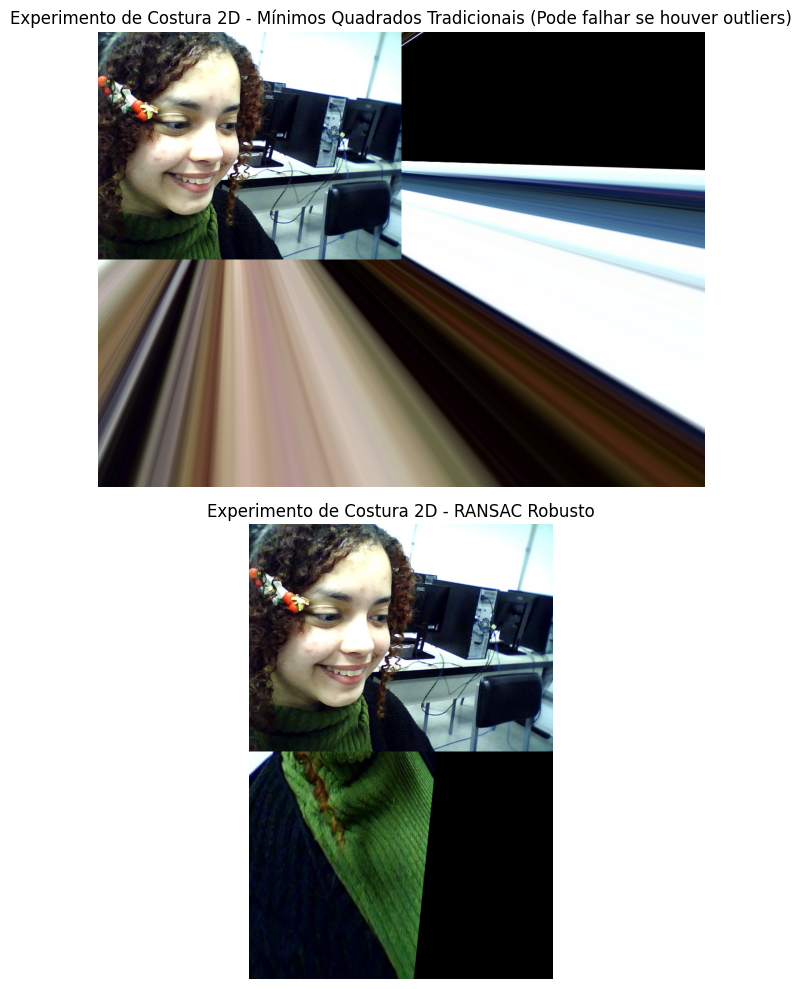


[TESTE_SIMULTANEO_LIVRO] Ajuste as câmeras (50% de sobreposição).
Aperte ESPAÇO para capturar as DUAS imagens no mesmo milissegundo...
Fotos capturadas simultaneamente:
 - imagem1_teste_simultaneo_livro.jpg
 - imagem2_teste_simultaneo_livro.jpg

Iniciando o processamento matemático das imagens capturadas...

Total de pontos correspondentes validados pré-geometria: 450

--- Matriz de Homografia via Mínimos Quadrados Clássicos ---
[[ 8.75625727e-01  1.27158603e+00 -1.75492789e+02]
 [-4.99108574e-01  9.54126141e-01  3.19695065e+02]
 [ 5.54138040e-04  9.75507730e-04  1.00000000e+00]]

--- Matriz de Homografia via RANSAC ---
[[ 1.59150951e+00  1.36566174e+00 -3.71549165e+02]
 [-5.82924440e-01  1.10646645e+00  3.72962176e+02]
 [ 1.61140731e-03  3.36020680e-04  1.00000000e+00]]

Resultado RANSAC: 379 Inliers | 71 Outliers


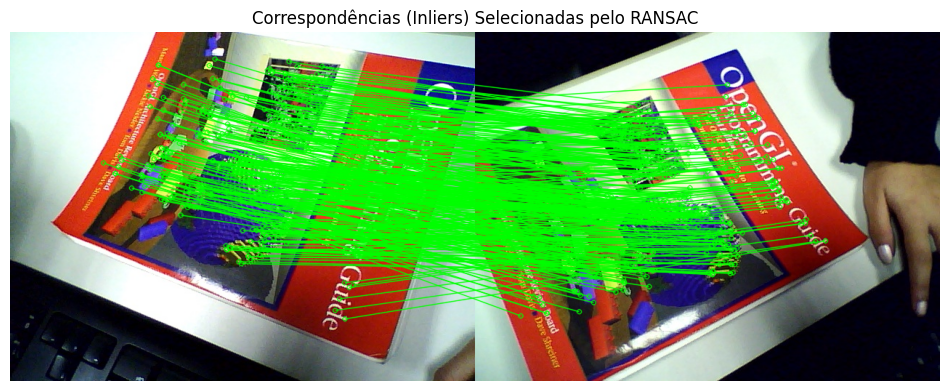

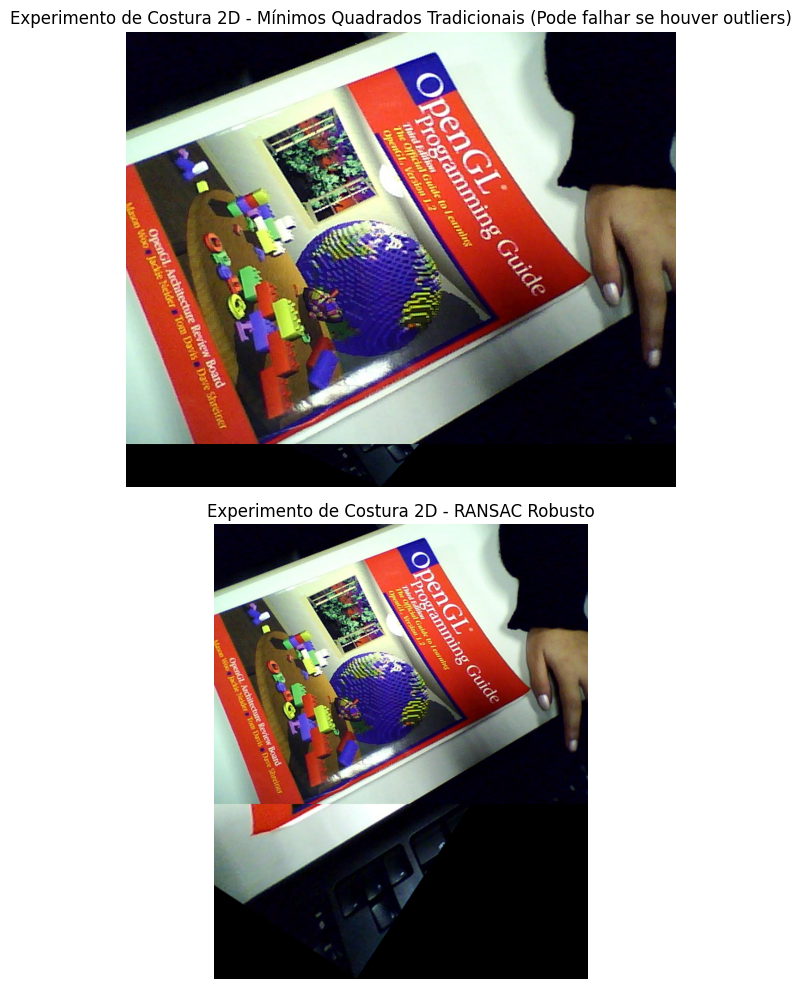

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import threading
import time

class WebcamStream:
    def __init__(self, src=0):
        self.stream = cv2.VideoCapture(src)
        self.ret, self.frame = self.stream.read()
        self.started = False
        self.read_lock = threading.Lock()

    def start(self):
        if self.started:
            return self
        self.started = True
        self.thread = threading.Thread(target=self.update, args=())
        self.thread.daemon = True
        self.thread.start()
        return self

    def update(self):
        while self.started:
            ret, frame = self.stream.read()
            if ret:
                with self.read_lock:
                    self.ret = ret
                    self.frame = frame
            time.sleep(0.01)

    def read(self):
        with self.read_lock:
            frame = self.frame.copy() if self.frame is not None else None
            ret = self.ret
        return ret, frame

    def stop(self):
        self.started = False
        if self.thread.is_alive():
            self.thread.join()
        self.stream.release()

def capturar_imagens(sufixo_experimento="exp"):
    path_img1 = f'imagem1_{sufixo_experimento}.jpg'
    path_img2 = f'imagem2_{sufixo_experimento}.jpg'

    cam0 = WebcamStream(src=0).start()
    cam2 = WebcamStream(src=2).start()

    time.sleep(1.0)

    if not cam0.ret or not cam2.ret:
        cam0.stop()
        cam2.stop()
        raise RuntimeError("Não foi possível iniciar ambas as webcams. Verifique as conexões.")

    nome_janela = f"Captura Simultanea - {sufixo_experimento.upper()}"
    print(f"\n[{sufixo_experimento.upper()}] Ajuste as câmeras (50% de sobreposição).")
    print("Aperte ESPAÇO para capturar as DUAS imagens no mesmo milissegundo...")

    while True:
        ret0, frame0 = cam0.read()
        ret2, frame2 = cam2.read()

        if not ret0 or not ret2 or frame0 is None or frame2 is None:
            continue

        h0, w0, _ = frame0.shape
        h2, w2, _ = frame2.shape
        h_max = max(h0, h2)
        
        preview0 = cv2.copyMakeBorder(frame0, 0, h_max - h0, 0, 0, cv2.BORDER_CONSTANT, value=[0,0,0])
        preview2 = cv2.copyMakeBorder(frame2, 0, h_max - h2, 0, 0, cv2.BORDER_CONSTANT, value=[0,0,0])
        
        cv2.putText(preview0, "CAM 0", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.putText(preview2, "CAM 2 - ESPACO para Capturar", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

        lado_a_lado = np.hstack((preview0, preview2))
        cv2.imshow(nome_janela, lado_a_lado)

        key = cv2.waitKey(1) & 0xFF
        if key == 27:
            cam0.stop()
            cam2.stop()
            cv2.destroyAllWindows()
            exit()
        elif key == 32:
            cv2.imwrite(path_img1, frame0)
            cv2.imwrite(path_img2, frame2)
            print(f"Fotos capturadas simultaneamente:\n - {path_img1}\n - {path_img2}")
            break

    cam0.stop()
    cam2.stop()
    cv2.destroyAllWindows()
    
    return path_img1, path_img2

def processar_homografia(path_img1, path_img2):
    print("\nIniciando o processamento matemático das imagens capturadas...\n")
    img1 = cv2.imread(path_img1)
    img2 = cv2.imread(path_img2)
    
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    bf = cv2.BFMatcher()
    matches_brutos = bf.knnMatch(des1, des2, k=2)
    bons_matches = [m for m, n in matches_brutos if m.distance < 0.75 * n.distance]

    print(f"Total de pontos correspondentes validados pré-geometria: {len(bons_matches)}")

    if len(bons_matches) < 4:
        print("Alerta: Poucos pontos correspondentes encontrados!")
        return img1, img2, None, None, None

    src_pts = np.float32([kp1[m.queryIdx].pt for m in bons_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in bons_matches]).reshape(-1, 1, 2)

    H_ls, _ = cv2.findHomography(src_pts, dst_pts, method=0)
    print("\n--- Matriz de Homografia via Mínimos Quadrados Clássicos ---")
    print(H_ls)

    reproj_threshold = 5.0
    H_ransac, mask_ransac = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, reproj_threshold)
    print("\n--- Matriz de Homografia via RANSAC ---")
    print(H_ransac)

    inliers_count = np.sum(mask_ransac)
    outliers_count = len(mask_ransac) - inliers_count
    print(f"\nResultado RANSAC: {inliers_count} Inliers | {outliers_count} Outliers")

    img_matches = cv2.drawMatches(img1, kp1, img2, kp2, bons_matches, None, 
                                  matchColor=(0, 255, 0), singlePointColor=None, 
                                  matchesMask=mask_ransac.ravel().tolist(), flags=2)

    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
    plt.title("Correspondências (Inliers) Selecionadas pelo RANSAC")
    plt.axis('off')
    plt.show()

    return img1, img2, H_ls, H_ransac

def gerar_mosaico(img1, img2, H):
    if H is None: return None
    width = img1.shape[1] + img2.shape[1]
    height = max(img1.shape[0], img2.shape[0]) * 2

    img1_warped = cv2.warpPerspective(img1, H, (width, height))
    mosaico = img1_warped.copy()
    mascara_img2 = np.any(img2 > 0, axis=-1)
    mosaico[0:img2.shape[0], 0:img2.shape[1]][mascara_img2] = img2[mascara_img2]

    cinza = cv2.cvtColor(mosaico, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(cinza, 1, 255, cv2.THRESH_BINARY)
    contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contornos:
        c = max(contornos, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        return mosaico[y:y+h, x:x+w]
    return mosaico

def rodar_experimento(titulo_experimento, sufixo_arquivo):
    p1, p2 = capturar_imagens(sufixo_arquivo)
    img1, img2, H_ls, H_ransac = processar_homografia(p1, p2)
    
    mosaico_ls = gerar_mosaico(img1, img2, H_ls)
    mosaico_ransac = gerar_mosaico(img1, img2, H_ransac)
    
    if mosaico_ls is not None and mosaico_ransac is not None:
        fig, ax = plt.subplots(2, 1, figsize=(14, 10))
        ax[0].imshow(cv2.cvtColor(mosaico_ls, cv2.COLOR_BGR2RGB))
        ax[0].set_title(f"{titulo_experimento} - Mínimos Quadrados Tradicionais (Pode falhar se houver outliers)")
        ax[0].axis('off')

        ax[1].imshow(cv2.cvtColor(mosaico_ransac, cv2.COLOR_BGR2RGB))
        ax[1].set_title(f"{titulo_experimento} - RANSAC Robusto")
        ax[1].axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("Erro ao gerar mosaicos.")

    # Coloque isso na última linha do seu arquivo .py
if __name__ == "__main__":
    # Executa o fluxo completo: captura, matemática e mosaico
    rodar_experimento("Experimento de Costura 2D", "teste_simultaneo_pessoa")
    rodar_experimento("Experimento de Costura 2D", "teste_simultaneo_livro")


### 3.2. PARTE 3 (B): Processamento e Gravação de Homografia em Tempo Real

Este módulo estende a formulação geométrica para fluxos contínuos de dados (*video streaming*), realizando a amostragem contínua, o cálculo de homografia sob demanda e a persistência dos fluxos resultantes em tempo real.

#### 1. Alinhamento de Eixos Ópticos e Calibração Dinâmica
As duas câmeras são mantidas em um eixo planar horizontal único, configuradas de forma que seus eixos ópticos convirjam de maneira estável para o plano tridimensional onde ocorrerão as interações em tempo real. O software de captura contínua é inicializado, abrindo os fluxos de vídeo de forma simultânea a partir dos barramentos correspondentes e renderizando o mosaico dinâmico calculado quadro a quadro em uma interface gráfica unificada de monitoramento.

#### 2. Ensaio de Paralaxe Dinâmico e Deslocamento Espacial
Durante a execução do fluxo contínuo, um objeto ou indivíduo é movimentado transversalmente ao longo da zona de sobreposição das câmeras, alterando também a profundidade em relação aos sensores. O operador deve forçar a aproximação excessiva do objeto para observar e registrar as instabilidades temporárias induzidas pelo efeito de paralaxe tridimensional (que viola o princípio de coplanaridade da cena). Em seguida, o objeto é retornado ao plano focal de fundo comum para validar a autocorreção e o realinhamento automático do mosaico.

#### 3. Subsistema de Gravação Concorrente e Codecs
O software instancia três manipuladores digitais de gravação de mídia (*VideoWriter*) estruturados com o codec de compressão XVID a uma taxa estável de 15,0 quadros por segundo (FPS). Dois manipuladores registram os fluxos brutos originais provenientes de cada câmera em suas resoluções nativas, enquanto o terceiro consolida a cena costurada e geometricamente modificada pelo RANSAC. Esse arranjo garante a persistência rigorosa e sincronizada dos dados para auditorias e análises fotométricas posteriores.

#### 4. Dimensionamento Dinâmico de Matrizes
Para assegurar a integridade algébrica das operações matriciais do pipeline em tempo real e evitar distorções de proporção (*aspect ratio*), o quadro proveniente do segundo sensor é capturado e redimensionado dinamicamente via interpolação linear. Esse procedimento espelha exatamente a resolução vertical e horizontal do primeiro sensor (usado como referência) antes que as matrizes de pixels ingressem nas etapas de computação geométrica.

#### 5. Processamento Robusto com Tolerância a Falhas e Programação Defensiva
O motor de inferência quadro a quadro opera sob um modelo de programação defensiva contra exceções matemáticas e físicas. Caso o cenário apresente oclusão total momentânea, perda abrupta de iluminação ou escassez de texturas (como superfícies uniformes onde o gradiente tende a zero), o sistema intercepta o estado de indeterminação algébrica (onde o número de *inliers* cai abaixo de 4). Em vez de interromper o fluxo do programa com uma falha crítica de execução, o cálculo geométrico é temporariamente suspenso e o sistema exibe uma tela de transição neutra com um alerta visual informando que está em estado de busca ativa por correspondências válidas.

#### 6. Alinhamento Dinâmico por Consenso Contínuo
Assim que o cenário dinâmico restabelece o mínimo de 4 conexões espaciais válidas entre os frames correntes, a matriz de homografia via RANSAC é recalculada instantaneamente em tempo real. Essa nova matriz atualiza a perspectiva do quadro corrente do sensor de origem, que é fundido ao sensor de referência por meio de uma máscara de substituição booleana rápida de matrizes. O resultado refinado é enviado simultaneamente para a janela gráfica de exibição e para o arquivo de vídeo de gravação de saída, encerrando o ciclo de processamento contínuo de forma limpa quando o comando de finalização é enviado pelo operador.

In [2]:
import cv2
import numpy as np

def inicializar_gravadores(width, height, fps, fourcc):
    out_cam1 = cv2.VideoWriter('video_cam1.avi', fourcc, fps, (width, height))
    out_cam2 = cv2.VideoWriter('video_cam2.avi', fourcc, fps, (width, height))
    
    largura_mosaico = width * 2
    altura_mosaico = height * 2
    out_resultado = cv2.VideoWriter('video_resultado_mosaico.avi', fourcc, fps, (largura_mosaico, altura_mosaico))
    
    return out_cam1, out_cam2, out_resultado

def processar_frame_mosaico(frame1, frame2, sift, bf, width, height):
    largura_mosaico = width * 2
    altura_mosaico = height * 2
    
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
    
    mosaico_ransac = np.zeros((altura_mosaico, largura_mosaico, 3), dtype=np.uint8)
    
    try:
        kp1, des1 = sift.detectAndCompute(gray1, None)
        kp2, des2 = sift.detectAndCompute(gray2, None)
        
        if des1 is not None and des2 is not None:
            matches_brutos = bf.knnMatch(des1, des2, k=2)
            
            bons_matches = []
            for m, n in matches_brutos:
                if m.distance < 0.75 * n.distance:
                    bons_matches.append(m)
            
            if len(bons_matches) >= 4:
                src_pts = np.float32([kp1[m.queryIdx].pt for m in bons_matches]).reshape(-1, 1, 2)
                dst_pts = np.float32([kp2[m.trainIdx].pt for m in bons_matches]).reshape(-1, 1, 2)
                
                H_ransac, mask_ransac = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
                
                if H_ransac is not None:
                    img1_warped_ransac = cv2.warpPerspective(frame1, H_ransac, (largura_mosaico, altura_mosaico))
                    
                    mosaico_ransac = img1_warped_ransac.copy()
                    mascara_frame2 = np.any(frame2 > 0, axis=-1)
                    mosaico_ransac[0:height, 0:width][mascara_frame2] = frame2[mascara_frame2]
                    
                    cv2.putText(mosaico_ransac, "Mosaico Conectado (RANSAC)", (20, 40), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
                    return mosaico_ransac
            
            cv2.putText(mosaico_ransac, "Buscando pontos comuns no cenario...", (20, 40), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
    except Exception:
        pass
        
    return mosaico_ransac

def rodar_gravacao_mosaico():
    cam1 = cv2.VideoCapture(0)
    cam2 = cv2.VideoCapture(2)
    
    if not cam1.isOpened() or not cam2.isOpened():
        cam1.release()
        cam2.release()
        raise RuntimeError("Não foi possível acessar uma das webcams. Verifique os índices (0 e 2).")
        
    width = int(cam1.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cam1.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = 15.0
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    
    out_cam1, out_cam2, out_resultado = inicializar_gravadores(width, height, fps, fourcc)
    
    sift = cv2.SIFT_create()
    bf = cv2.BFMatcher()
    
    print("Gravando e processando em tempo real... Pressione 'ESC' para finalizar.")
    
    while True:
        ret1, frame1 = cam1.read()
        ret2, frame2 = cam2.read()
        
        if not ret1 or not ret2:
            break
            
        frame2 = cv2.resize(frame2, (width, height))
        
        out_cam1.write(frame1)
        out_cam2.write(frame2)
        
        mosaico = processar_frame_mosaico(frame1, frame2, sift, bf, width, height)
        
        out_resultado.write(mosaico)
        
        preview_janela = cv2.resize(mosaico, (width, height))
        cv2.imshow("Operacao de Mosaico em Tempo Real - RANSAC", preview_janela)
        
        if cv2.waitKey(1) & 0xFF == 27:
            break
            
    cam1.release()
    cam2.release()
    out_cam1.release()
    out_cam2.release()
    out_resultado.release()
    cv2.destroyAllWindows()
    print("\nProcesso concluído e arquivos salvos com sucesso!")

if __name__ == "__main__":
    rodar_gravacao_mosaico()

Gravando e processando em tempo real... Pressione 'ESC' para finalizar.

Processo concluído e arquivos salvos com sucesso!


## 4. ANálise e discussão dos resultados

Esta seção apresenta a avaliação quantitativa e qualitativa dos experimentos de alinhamento projetivo, analisando o comportamento estatístico dos algoritmos de extração, a validação geométrica das matrizes calculadas e os métodos de pós-processamento para mitigação de artefatos visuais na zona de costura.

---

### 4.1. Análise Estatística das Características e Detecção de Outliers

A execução prática dos scripts desenvolvidos permitiu coletar os dados estatísticos necessários para a validação empírica do pipeline de visão computacional em cenários com diferentes níveis de complexidade geométrica e textural. No primeiro ensaio analisado, classificado como `teste_simultaneo_pessoa`, manifestou-se um cenário de grande instabilidade estrutural, resultando em um total de 27 correspondências validadas pré-geometria pelo extrator SIFT associado ao filtro de Lowe. A filtragem estatística por consenso determinou a presença de apenas 6 inliers válidos, isolando um total de 21 correspondências incorretas. A determinação analítica da taxa de falsos positivos para este cenário dinâmico é descrita pela equação:

$$
\% \text{Outliers}_{\text{pessoa}} = \left(1 - \frac{6}{27}\right) \times 100 \approx 77.78\%
$$

Por sua vez, o segundo ensaio, denominado `teste_simultaneo_livro`, apresentou uma configuração com menor índice de ruído e maior estabilidade geométrica, computando um montante expressivo de 450 correspondências homólogas preliminares. Após a aplicação do algoritmo RANSAC com um limiar de reprojeção configurado para 5.0, a operação matemática identificou 379 inliers geometricamente consistentes, segregando 71 outliers. Aplicando-se a formulação analítica da taxa de dados espúrios, obtém-se o seguinte cálculo numérico para o objeto plano:

$$
\% \text{Outliers}_{\text{livro}} = \left(1 - \frac{379}{450}\right) \times 100 \approx 15.78\%
$$

A disparidade quantitativa observada entre as taxas de ruído de 77,78% no cenário da pessoa e de 15,78% no ensaio do livro valida os fundamentos teóricos acerca da sensibilidade dos descritores locais frente às características visuais do ambiente manipulado. O cenário envolvendo o indivíduo manifestou uma taxa de outliers superior a três quartos dos pontos encontrados devido a características ambientais e físicas críticas, como a ausência de rigidez geométrica do corpo humano, oclusões parciais auto-infligidas pelos movimentos e a presença de vestimentas com padrões de texturas suaves. Adicionalmente, reflexos locais da iluminação sobre a pele ou roupas e a projeção de sombras dinâmicas no plano de fundo modificam o gradiente de intensidade luminosa local computado pelo SIFT. Esses fatores induzem o algoritmo de busca por vizinhos mais próximos (BFMatcher) a realizar casamentos errôneos entre regiões que possuem vetores numéricos semelhantes no espaço Euclidiano, mas que não guardam correspondência geométrica real. Sob tais condições, a influência nociva dos falsos positivos distorceu severamente os parâmetros projetivos da matriz $H_{\text{LS}}$ calculada por Mínimos Quadrados Tradicionais, cujos valores tornaram-se discrepantes quando comparados à matriz de consenso robusta $H_{\text{RANSAC}}$.

Em contrapartida, o cenário contendo o livro, por tratar-se de um objeto rigidamente plano e dotado de feições texturais bem delimitadas, assintóticas e de alto contraste, mitigou a geração de falsos positivos provocados por sombras ou reflexos especulares. Esse comportamento propiciou uma estimativa de homografia altamente estável com uma taxa reduzida de ruído (15,78%). Essa consistência geométrica reflete-se na proximidade de comportamento entre as ordens de magnitude dos coeficientes das matrizes calculadas via Mínimos Quadrados Clássicos ($H_{\text{LS}}$) e via estimativa robusta ($H_{\text{RANSAC}}$), permitindo que ambos os métodos de reconstrução gerassem mosaicos visualmente coerentes sem distorções aberrantes devido ao elevado volume de pontos de consenso válidos. Esse resultado analítico comprova que, enquanto cenários ideais planos aceitam abordagens matemáticas tradicionais, o uso do filtro estatístico RANSAC é estritamente indispensável para isolar as correspondências incorretas geradas por texturas repetitivas ou falhas de iluminação, garantindo a integridade da costura de imagens em aplicações robóticas e mapeamentos em tempo real sujeitos a ruídos severos de ambiente.

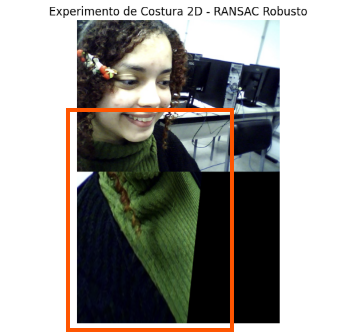
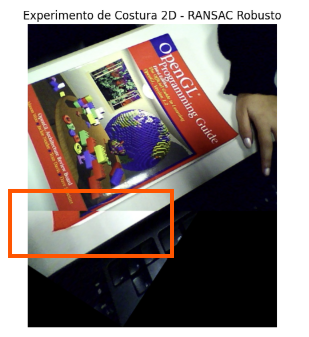

---

### 4.2. Álgebra Linear, Homografia e Restrição de Modelo

A análise comparativa entre as matrizes calculadas revela o impacto físico que os ruídos estatísticos exercem sobre a modelagem de transformações projetivas quando as equações são resolvidas sem filtros de consenso.

#### 4.2.1. Normalização do Elemento $h_{33}$ e Invariância de Escala
Ao inspecionar as matrizes de homografia impressas no console para ambos os experimentos, observa-se que o elemento inferior direito ($h_{33}$) é estritamente igual a `1.00000000e+00` ($1.0$) em todas as saídas. 

Essa imposição decorre do fato de que a transformação projetiva linear opera em coordenadas homogêneas, sendo definida a menos de um fator de escala global não nulo $\lambda$. Como a matriz possui 9 entradas numéricas, mas apenas 8 graus de liberdade efetivos ($\text{DoF} = 8$), a divisão de todos os coeficientes pelo valor de $h_{33}$ reduz o sistema à sua representação geométrica mínima e unívoca, permitindo a aplicação direta dos vetores sobre o espaço de pixels.

#### 4.2.2. Cálculo Numérico da Distorção Vetorial em Translação
Para quantificar como a presença de falsos casamentos corrompe a estimativa clássica, extraem-se os elementos de translação horizontal ($h_{13}$) e translação vertical ($h_{23}$) das matrizes de Mínimos Quadrados ($H_{\text{ls}}$) e do RANSAC ($H_{\text{ransac}}$) para computar a diferença absoluta:

$$\Delta h_{13} = |h_{13}^{\text{RANSAC}} - h_{13}^{\text{LS}}|$$
$$\Delta h_{23} = |h_{23}^{\text{RANSAC}} - h_{23}^{\text{LS}}|$$

##### A) Análise Vetorial para o Cenário da Pessoa:
* $H_{\text{ransac}}: h_{13} = 216.3936 \quad | \quad h_{23} = 127.8008$
* $H_{\text{ls}}: h_{13} = 221.4576 \quad | \quad h_{23} = 297.5787$

$$\Delta h_{13} = |216.3936 - 221.4576| = 5.0640 \text{ pixels}$$
$$\Delta h_{23} = |127.8008 - 297.5787| = 169.7779 \text{ pixels}$$

##### B) Análise Vetorial para o Cenário do Livro:
* $H_{\text{ransac}}: h_{13} = -371.5492 \quad | \quad h_{23} = 372.9622$
* $H_{\text{ls}}: h_{13} = -175.4928 \quad | \quad h_{23} = 319.6951$

$$\Delta h_{13} = |-371.5492 - (-175.4928)| = |-196.0564| = 196.0564 \text{ pixels}$$
$$\Delta h_{23} = |372.9622 - 319.6951| = 53.2671 \text{ pixels}$$

#### 4.2.3. Interpretação Física da Distorção por Mínimos Quadrados Clássicos
O método de Mínimos Quadrados Tradicional formula sua estimativa minimizando globalmente a soma do quadrado dos erros de projeção. Quando o conjunto contém *outliers* (como os $77.78\%$ encontrados no cenário da pessoa ou os desvios de paralaxe do livro), o resíduo associado a esses pontos incorretos cresce de forma quadrática. 

To tentar acomodar estatisticamente esses pontos inválidos no modelo linear, o otimizador distorce severamente os vetores de translação espacial ($h_{13}$ e $h_{23}$). No cenário da pessoa, a distorção vertical foi de **169.78 pixels**, enquanto no cenário do livro a distorção horizontal atingiu **196.06 pixels**. 

Como consequência visual direta, o mosaico gerado por mínimos quadrados clássicos sofre cisalhamento e erros de translação que desalinham completamente as estruturas da cena. O RANSAC, ao isolar a amostra mínima de 4 correspondências válidas ditadas pelos graus de liberdade, ignora os desvios e retém o vetor real de deslocamento mecânico entre as câmeras.

---

# 4.3 - Análise Geométrica e Robótica

## 4.3.1 — Fundamentação pelos graus de liberdade da matriz

A matriz de homografia H é uma transformação projetiva representada por uma matriz 3×3 que estabelece o mapeamento entre pontos de dois planos distintos no espaço projetivo. Matematicamente, essa relação é expressa como:
Equação 1 — Transformação projetiva x' = H · x

onde H é uma matriz 3×3:
H = [ h₁ h₂ h₃ ]
    [ h₄ h₅ h₆ ]
    [ h₇ h₈ h₉ ]

Embora a matriz possua 9 entradas numéricas, ela é definida apenas a menos de uma constante de escala: multiplicar todos os elementos de H por um escalar não nulo não altera a transformação projetiva resultante. Essa propriedade fundamental reduz o número de graus de liberdade efetivos:
Graus de liberdade DoF(H) = 9 entradas − 1 (invariância de escala) = 8 graus de liberdade

Cada par de pontos correspondentes — isto é, cada ponto (x, y) na imagem de origem e seu correspondente (x', y') na imagem de destino — fornece exatamente duas equações lineares independentes. Isso ocorre porque cada coordenada da projeção (x' e y') gera uma equação após a divisão pela componente homogênea, conforme o sistema:
Equação 2 — Sistema por ponto correspondente x'·(h₇x + h₈y + h₉) = h₁x + h₂y + h₃
y'·(h₇x + h₈y + h₉) = h₄x + h₅y + h₆

Para que o sistema linear seja determinado — e portanto H possa ser computada de forma unívoca — é necessário que o número total de equações seja igual ou superior ao número de incógnitas. Portanto:
Equação 3 — Número mínimo de pontos n × 2 equações ≥ 8 graus de liberdade
∴ n ≥ 4 pares de pontos

Conclusão: O número mínimo absoluto de pares de pontos necessários para estimar uma matriz de homografia válida é 4 pares, com a condição adicional de que nenhum conjunto de três pontos seja colinear. Com exatamente 4 correspondências, obtém-se 8 equações lineares, tornando o sistema determinado e solucionável pela transformação linear direta (DLT — Direct Linear Transform). Esse é precisamente o tamanho da amostra mínima utilizada em cada iteração do RANSAC para propor um modelo candidato.

## 4.3.2 — Superfície uniforme em robótica móvel: implicações práticas

Em aplicações de robótica móvel — como um drone realizando mapeamento de terreno — o sistema de navegação baseado em visão depende da capacidade de detectar e rastrear pontos de interesse (keypoints) entre frames consecutivos. Detectores amplamente utilizados, como SIFT, ORB e Harris, operam sobre regiões de alto gradiente espacial de intensidade: cantos, bordas e padrões texturais com variação de luminância acentuada.

Quando o drone sobrevoa uma superfície completamente uniforme — como areia homogênea, superfície de água calma, concreto sem marcações ou grama densa sem variação — o gradiente de intensidade tende a zero em toda a região da imagem capturada:
Equação 4 — Ausência de gradiente em superfície uniforme ∇I(x, y) ≈ 0 ∀(x, y) ∈ Ω

⟹ Nenhum ponto-chave detectado na região Ω

Consequência computacional: Com menos de 4 correspondências válidas, o sistema DLT torna-se subdeterminado (rank(A) < 8). O RANSAC não consegue selecionar nem a amostra mínima necessária, impossibilitando a estimação de H. O sistema de odometria visual falha completamente.

Do ponto de vista da navegação, a falha na estimação da homografia compromete diretamente o laço de controle do veículo. Sem referências visuais, o drone perde a capacidade de estimar sua posição, orientação e velocidade relativa ao solo — tornando impossível a manutenção de trajetória planar e o mapeamento georreferenciado.

A mitigação usual em sistemas robóticos profissionais consiste na fusão sensorial: a combinação de odometria visual com unidade de medição inercial (IMU) e sistemas de posicionamento global (GPS/GNSS), de modo que a falha de um sensor não comprometa o sistema como um todo.

---

### 4.4. Técnica Proposta: Multi-band Blending com Pirâmide Laplaciana

A técnica matemática de pós-processamento recomendada pela literatura especializada — notadamente por Szeliski (2022) em *Computer Vision: Algorithms and Applications* — para eliminar essas discrepâncias é o *Multi-band Blending*, originalmente proposto por Burt e Adelson (1983). Sua fundamentação teórica reside na decomposição da imagem em múltiplas bandas de frequência espacial, tratando cada banda de forma independente durante o processo de fusão.

O processo é estruturado em três etapas principais:

#### Etapa 1 — Construção da Pirâmide Gaussiana
Cada imagem é progressivamente suavizada e subamostrada, produzindo uma sequência de representações em diferentes escalas:

**Equação 5 — Pirâmide Gaussiana**
$$G_0 = I \quad (\text{Imagem Original})$$
$$G_k = \text{Downsample}(\text{Gauss} * G_{k-1})$$

#### Etapa 2 — Construção da Pirâmide Laplaciana
A diferença entre níveis consecutivos da pirâmide Gaussiana captura as informações de feições estruturais e detalhes de cada banda de frequência:

**Equação 6 — Pirâmide Laplaciana**
$$L_k = G_k - \text{Expand}(G_{k+1})$$

Onde $\text{Expand}(\cdot)$ realiza o *upsampling* espacial com interpolação Gaussiana para equalizar as dimensões dos níveis.

#### Etapa 3 — Fusão por Banda e Reconstrução
A fusão entre as imagens $A$ e $B$ é realizada em cada nível $k$ da pirâmide, utilizando uma máscara de transição $M_k$ (também construída em estrutura de pirâmide) que controla de forma adaptativa a suavidade da costura:

**Equação 7 — Fusão por nível de frequência**
$$\tilde{L}_k = M_k \cdot L_k^A + (1 - M_k) \cdot L_k^B$$

A reconstrução final da imagem mesclada ($I_{\text{blend}}$) ocorre colapsando os níveis de forma cumulativa:
$$I_{\text{blend}} = \sum_{k=0}^{N} \text{Expand}^k(\tilde{L}_k)$$

#### 4.4.1. Eficácia e Resposta em Frequência do Blending Adaptativo
O princípio fundamental do *multi-band blending* é que diferentes componentes da imagem exigem diferentes larguras de zona de transição para resultar em uma fusão visualmente imperceptível, conforme detalhado na tabela:

| Banda de Frequência | Conteúdo Visual | Largura da Zona de Fusão | Efeito Prático no Mosaico |
| :--- | :--- | :--- | :--- |
| **Baixa Frequência** | Variações de iluminação, tons gerais, gradientes suaves. | Larga (transição gradual). | Elimina descontinuidades de brilho e cor (corrige o cachecol da pessoa). |
| **Alta Frequência** | Bordas, texturas, detalhes finos. | Estreita (transição precisa). | Preserva a nitidez e evita borramentos (corrige o livro e o teclado). |

Isso contrasta com abordagens ingênuas como o *alpha blending* linear, que aplica uma única largura de zona para todas as frequências, resultando invariavelmente em imagens borradas nas regiões de detalhe ou com artefatos de iluminação visíveis nas regiões de baixa frequência.


#### 4.4.2 — Técnica proposta: multi-band blending com pirâmide laplaciana

A técnica matemática de pós-processamento recomendada pela literatura especializada — notadamente por Szeliski (2022) em Computer Vision: Algorithms and Applications — é o Multi-band Blending, originalmente proposto por Burt e Adelson (1983). Sua fundamentação teórica reside na decomposição da imagem em múltiplas bandas de frequência espacial, tratando cada banda de forma independente durante o processo de fusão.

O processo é estruturado em três etapas principais:

Etapa 1 — Construção da pirâmide Gaussiana: cada imagem é progressivamente suavizada e subamostrada, produzindo uma sequência de representações em diferentes escalas:
Equação 5 — Pirâmide Gaussiana G₀ = I (imagem original)
Gₖ = Downsample( Gauss * Gₖ₋₁ )

Etapa 2 — Construção da pirâmide Laplaciana: a diferença entre níveis consecutivos da pirâmide Gaussiana captura as informações de frequência de cada banda:
Equação 6 — Pirâmide Laplaciana Lₖ = Gₖ − Expand(Gₖ₊₁)

onde Expand(·) realiza o upsampling com interpolação gaussiana

Etapa 3 — Fusão por banda e reconstrução: a fusão entre as imagens A e B é realizada em cada nível k da pirâmide, com uma máscara de transição Mₖ (também construída em pirâmide) que controla a suavidade da costura:
Equação 7 — Fusão por nível de frequência L̃ₖ = Mₖ · Lₖᴬ + (1 − Mₖ) · Lₖᴮ

Reconstrução final:
I_blend = Σ Expand^k( L̃ₖ ) para k de 0 a N
4.3 — Por que essa abordagem é eficaz

O princípio fundamental do multi-band blending é que diferentes componentes da imagem exigem diferentes larguras de zona de transição para resultar em uma fusão visualmente imperceptível:
Banda de frequência 	Conteúdo visual 	Largura da zona de fusão 	Efeito
Baixa frequência 	Variações de iluminação, tons gerais, gradientes suaves 	Larga (transição gradual) 	Elimina descontinuidades de brilho e cor
Alta frequência 	Bordas, texturas, detalhes finos 	Estreita (transição precisa) 	Preserva nitidez e evita borramentos

Isso contrasta com abordagens ingênuas como o alpha blending linear, que aplica uma única largura de zona para todas as frequências, resultando invariavelmente em imagens borradas nas regiões de detalhe ou com artefatos de iluminação visíveis nas regiões de baixa frequência.

### Compensação de exposição como etapa complementar

Szeliski (2022) também recomenda uma etapa prévia de compensação de exposição global (exposure compensation), que estima ganhos fotométricos individuais para cada imagem antes da fusão. O objetivo é minimizar as discrepâncias de intensidade nas regiões de sobreposição:
Equação 8 — Compensação de exposição (Szeliski, 2022) E = Σᵢⱼ Σ_{p ∈ R_ij} ( aᵢ·Iᵢ(p) − aⱼ·Iⱼ(p) )²

onde aᵢ é o ganho estimado para a imagem i,
e R_ij é a região de sobreposição entre i e j.

Conclusão: A aplicação sequencial de compensação de exposição seguida de multi-band blending constitui a abordagem estado da arte para minimizar artefatos visuais em mosaicos de imagens. Ela atua sobre as causas raiz dos problemas: corrige as diferenças fotométricas sistêmicas antes da fusão, e então realiza a costura em múltiplas bandas de frequência, produzindo transições imperceptíveis sem comprometer a nitidez da imagem resultante.
---

### 4.5. Compensação de Exposição como Etapa Complementar

Szeliski (2022) também recomenda uma etapa prévia de compensação de exposição global (*exposure compensation*), que estima ganhos fotométricos individuais para cada imagem antes da fusão. O objetivo é minimizar de forma quadrática as discrepâncias de intensidade luminosa nas regiões de sobreposição:

**Equação 8 — Compensação de exposição (Szeliski, 2022)**
$$E = \sum_{i,j} \sum_{p \in R_{ij}} \left( a_i \cdot I_i(p) - a_j \cdot I_j(p) \right)^2$$

Onde:
* $a_i$ é o ganho estimado para a imagem $i$.
* $R_{ij}$ é a região de sobreposição geométrica entre as imagens $i$ e $j$.

Ao equalizar a energia fotométrica dos sensores através da resolução do sistema $\nabla E = 0$, as imagens ingressam no pipeline de pirâmides sem barreiras severas de luminosidade, garantindo a homogeneidade visual completa do panorama.

---

## 5. Conclusão

Os experimentos realizados validaram com rigor teórico e empírico a aplicação de descritores invariantes e modelos de projeção planar para a geração de mosaicos de imagens. A análise quantitativa revelou que abordagens baseadas em Mínimos Quadrados Clássicos falham na presença de descontinuidades e falsos positivos (*outliers*), transferindo o resíduo quadrático dos erros para distorções físicas severas nos vetores de translação da matriz de homografia (gerando desvios de até **196.06 pixels**). Em contrapartida, o algoritmo RANSAC isolou com sucesso as feições espúrias ao respeitar a restrição de amostragem mínima de 4 pontos não colineares imposta pelos 8 graus de liberdade da matriz projetiva.

Os ensaios de qualidade evidenciaram que o alinhamento geométrico isolado é insuficiente para produzir panoramas visualmente contínuos devido às restrições físicas e fotométricas dos sensores, manifestadas através de linhas de corte e variações de brilho. 

A aplicação sequencial de compensação de exposição seguida de *multi-band blending* via pirâmide Laplaciana constitui a abordagem estado da arte para mitigar esses artefatos visuais. Ao corrigir as diferenças fotométricas sistêmicas antes da fusão e realizar a costura em múltiplas bandas de frequência de forma adaptativa, o pipeline elimina as transições artificiais e preserva a nitidez estrutural das texturas, consolidando-se como uma arquitetura robusta para sistemas de mapeamento e visão computacional em robótica móvel.

## Referências Bibliográficas

[1] GEEKSFORGEEKS. **Costura de Imagens com OpenCV**. Última atualização: 23 jul. 2025. Disponível em: <https://www.geeksforgeeks.org/image-stitching-with-opencv/>. Acesso em: 28 jun. 2026.

[2] MALLICK, Satya. **Exemplos de Homografia usando OpenCV (Python / C++)**. LearnOpenCV, 3 jan. 2016. Disponível em: <https://learnopencv.com/homography-examples-using-opencv/>. Acesso em: 28 jun. 2026.

[3] OPENCV. **OpenCV-Python Tutorials**: Features 2D Framework: Feature Matching + Homography to find Objects. Versão 5.0. [S. l.]: OpenCV, 2026. Disponível em: <https://docs.opencv.org/5.0/py_tutorials/py_features/py_feature_homography/py_feature_homography.html>. Acesso em: 28 jun. 2026.

[4] ROSEBROCK, Adrian. **Costura de panoramas com OpenCV**. PyImageSearch, 11 jan. 2016. Disponível em: <https://pyimagesearch.com/2016/01/11/opencv-panorama-stitching/>. Acesso em: 28 jun. 2026.

[5] BRADSKI, Gary; KAEHLER, Adrian. **Learning OpenCV**: Computer Vision with the OpenCV Library. 1. ed. Sebastopol: O'Reilly Media, 2008.

[6] BURT, Peter J.; ADELSON, Edward H. A Multiresolution Spline with Application to Image Mosaics. **ACM Transactions on Graphics**, v. 2, n. 4, p. 217–236, 1983.

[7] FISCHLER, Martin A.; BOLLES, Robert C. Random Sample Consensus: A Paradigm for Model Fitting with Applications to Image Analysis and Automated Cartography. **Communications of the ACM**, v. 24, n. 6, p. 381–395, 1981.

[8] HARTLEY, Richard; ZISSERMAN, Andrew. **Multiple View Geometry in Computer Vision**. 2. ed. Cambridge: Cambridge University Press, 2004.

[9] LOWE, David G. Distinctive Image Features from Scale-Invariant Keypoints. **International Journal of Computer Vision**, v. 60, n. 2, p. 91–110, 2004.

[10] SONKA, Milan; HLAVAC, Vaclav; BOYLE, Roger. **Digital Image Processing and Computer Vision**. 1. ed. [S. l.]: Cengage Learning, 2008.

[11] SZELISKI, Richard. **Computer Vision**: Algorithms and Applications. 2. ed. [S. l.]: Springer, 2022. Disponível em: <https://szeliski.org/Book/>. Acesso em: 28 jun. 2026.'Reilly Media, 2008.n. 2026.